# ECG_CRNN on PTB-XL — Multi-Label 12-Lead Classification

**Model:** ECG_CRNN (ResNet CNN backbone + BiLSTM head) from [torch_ecg](https://github.com/DeepPSP/torch_ecg)  
**Dataset:** PTB-XL — preprocessed `.pickle` files (17 111 train / 2 156 val / 2 163 test)  
**Task:** Multi-label classification of 4 superclasses — **MI, STTC, CD, HYP**

| Class | Full Name | Meaning |
|-------|-----------|--------|
| MI    | Myocardial Infarction | Heart attack / ischemia |
| STTC  | ST/T-wave Change | Repolarisation abnormality |
| CD    | Conduction Disturbance | Bundle branch block, AV block |
| HYP   | Hypertrophy | Ventricular/atrial enlargement |

## 0 · Install dependencies

In [1]:
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

# Install torch_ecg and supporting libraries if not present
try:
    import torch_ecg
    print(f'torch_ecg {torch_ecg.__version__} already installed')
except ImportError:
    print('Installing torch_ecg …')
    pip_install('torch-ecg>=0.0.29')

try:
    import sklearn
except ImportError:
    pip_install('scikit-learn')

try:
    import seaborn
except ImportError:
    pip_install('seaborn')

try:
    import captum
except ImportError:
    print('Installing captum (for XAI) …')
    pip_install('captum')

print('All dependencies ready.')

Installing torch_ecg …
All dependencies ready.


## 1 · Imports & config

In [2]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from copy import deepcopy
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    confusion_matrix, f1_score, classification_report,
    roc_auc_score, multilabel_confusion_matrix
)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Paths ──────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path('.')
PKL_DIR      = Path('../PTB-XL-ECG')
CKPT_DIR     = NOTEBOOK_DIR / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

# ── Classes ────────────────────────────────────────────────────────────────────
CLASS_NAMES  = ['MI', 'STTC', 'CD', 'HYP']
NUM_CLASSES  = len(CLASS_NAMES)

# ── Hyperparameters ────────────────────────────────────────────────────────────
BATCH_SIZE     = 256
EPOCHS         = 50
LR             = 3e-4
WEIGHT_DECAY   = 1e-4
PATIENCE       = 15          # epochs without val F1 improvement before stopping
WARMUP_EPOCHS  = 5           # skip F1 tracking for the first N epochs (random-init fluke)
THRESHOLD      = 0.5
USE_FOCAL      = True
FOCAL_GAMMA    = 2.0
FOCAL_ALPHA    = 0.25

DEVICE = (
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Device: {DEVICE}')
print(f'Batch size: {BATCH_SIZE} | LR: {LR} | Loss: {"Focal" if USE_FOCAL else "Weighted BCE"}')
print(f'Patience: {PATIENCE} | Warmup epochs: {WARMUP_EPOCHS}')


Device: cuda
Batch size: 256 | LR: 0.0003 | Loss: Focal
Patience: 15 | Warmup epochs: 5


## 2 · Load preprocessed data

In [3]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

X_train = np.array(load_pkl(PKL_DIR / 'X_train_processed.pickle'), dtype=np.float32)  # (N,1000,12)
y_train = np.array(load_pkl(PKL_DIR / 'y_train_processed.pickle'), dtype=np.float32)  # (N,4)

X_val   = np.array(load_pkl(PKL_DIR / 'X_dev_processed.pickle'),   dtype=np.float32)
y_val   = np.array(load_pkl(PKL_DIR / 'y_dev_processed.pickle'),   dtype=np.float32)

X_test  = np.array(load_pkl(PKL_DIR / 'X_test_processed.pickle'),  dtype=np.float32)
y_test  = np.array(load_pkl(PKL_DIR / 'y_test_processed.pickle'),  dtype=np.float32)

# torch_ecg expects (batch, leads, time) — transpose from (N, time, leads)
X_train = X_train.transpose(0, 2, 1)   # → (N, 12, 1000)
X_val   = X_val.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)

# A sample with all-zero label vector is a healthy (NORM) ECG.
# A sample can also carry multiple positive labels simultaneously (multi-label).
norm_train = (y_train.sum(axis=1) == 0)
norm_val   = (y_val.sum(axis=1)   == 0)
norm_test  = (y_test.sum(axis=1)  == 0)

print(f'Train  X: {X_train.shape}  y: {y_train.shape}')
print(f'Val    X: {X_val.shape}    y: {y_val.shape}')
print(f'Test   X: {X_test.shape}   y: {y_test.shape}')
print()
print(f'Healthy (NORM) samples — train: {norm_train.sum()} ({100*norm_train.mean():.1f}%)')
print(f'                          val:   {norm_val.sum()} ({100*norm_val.mean():.1f}%)')
print(f'                          test:  {norm_test.sum()} ({100*norm_test.mean():.1f}%)')
print()
multi_train = (y_train.sum(axis=1) > 1)
print(f'Multi-disease samples   — train: {multi_train.sum()} ({100*multi_train.mean():.1f}%)')
print()
print('Class prevalence (train):')
print(f'  {"NORM":5s}: {int(norm_train.sum()):5d}  ({100*norm_train.mean():.1f}%) — healthy ECG (all labels = 0)')
for c, n in zip(CLASS_NAMES, y_train.sum(axis=0)):
    print(f'  {c:5s}: {int(n):5d}  ({100*n/len(y_train):.1f}%)')


Train  X: (17111, 12, 1000)  y: (17111, 4)
Val    X: (2156, 12, 1000)    y: (2156, 4)
Test   X: (2163, 12, 1000)   y: (2163, 4)

Healthy (NORM) samples — train: 7254 (42.4%)
                          val:   916 (42.5%)
                          test:  913 (42.2%)

Multi-disease samples   — train: 3785 (22.1%)

Class prevalence (train):
  NORM :  7254  (42.4%) — healthy ECG (all labels = 0)
  MI   :  4389  (25.7%)
  STTC :  4193  (24.5%)
  CD   :  3912  (22.9%)
  HYP  :  2121  (12.4%)


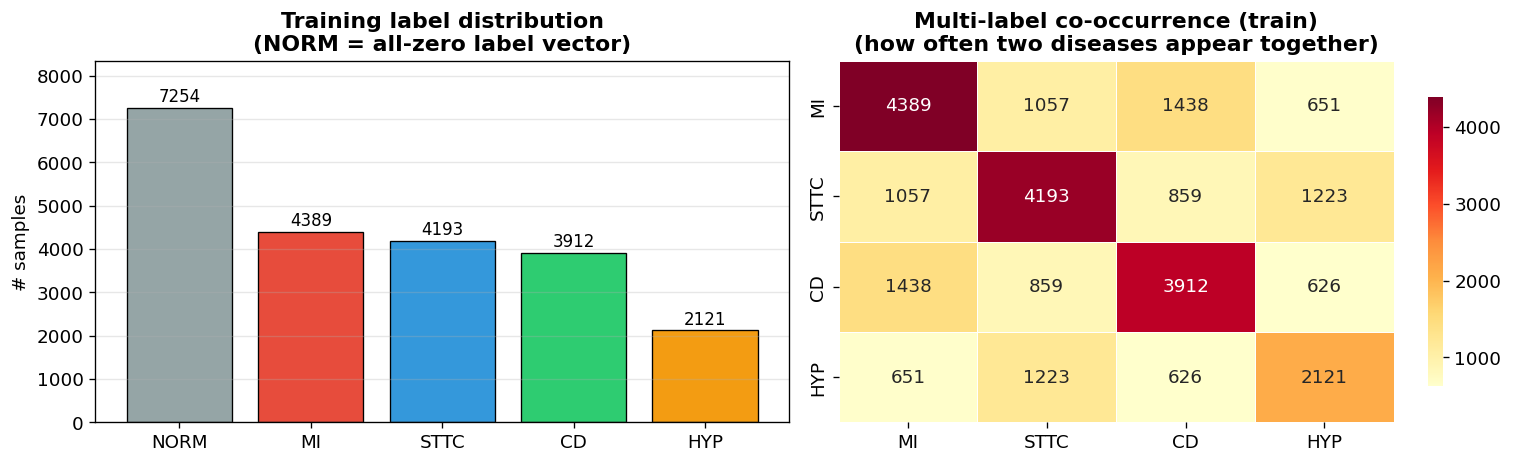

In [4]:
all_labels = ['NORM'] + CLASS_NAMES
all_counts = np.array([norm_train.sum()] + list(y_train.sum(axis=0)))
bar_colors = ['#95a5a6', '#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: class distribution including NORM ───────────────────────────────
ax = axes[0]
bars = ax.bar(all_labels, all_counts, color=bar_colors, edgecolor='k', linewidth=0.8)
for bar, cnt in zip(bars, all_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{int(cnt)}', ha='center', va='bottom', fontsize=10)
ax.set_title('Training label distribution\n(NORM = all-zero label vector)', fontweight='bold')
ax.set_ylabel('# samples')
ax.set_ylim(0, max(all_counts) * 1.15)
ax.grid(True, axis='y', alpha=0.3)

# ── Right: multi-label co-occurrence heatmap ──────────────────────────────
ax = axes[1]
co = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        co[i, j] = int(((y_train[:, i] == 1) & (y_train[:, j] == 1)).sum())
sns.heatmap(co, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Multi-label co-occurrence (train)\n(how often two diseases appear together)',
             fontweight='bold')

plt.tight_layout()
plt.savefig(CKPT_DIR / 'label_distribution.png', bbox_inches='tight')
plt.show()


## 3 · Dataset, NORM undersampling & stratified split

In [5]:
class ECGDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X)   # (N, 12, 1000)
        self.y = torch.from_numpy(y)   # (N, 4)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ── Pool all three original splits ────────────────────────────────────────────
X_all = np.concatenate([X_train, X_val, X_test], axis=0)   # (21430, 12, 1000)
y_all = np.concatenate([y_train, y_val, y_test], axis=0)   # (21430, 4)

print(f'Pooled dataset: X={X_all.shape}  y={y_all.shape}')

# ── Undersample NORM to reduce majority-class dominance ──────────────────────
# NORM samples (all-zero label vectors) make up ~42% of the pooled data.
# Capping them at NORM_CAP brings their proportion down to ~25%, closer to the
# disease-class frequencies, so the model sees a more balanced training signal.
NORM_CAP    = 4000
rng         = np.random.default_rng(SEED)
norm_idx    = np.where(y_all.sum(axis=1) == 0)[0]
disease_idx = np.where(y_all.sum(axis=1) > 0)[0]

if len(norm_idx) > NORM_CAP:
    norm_idx = rng.choice(norm_idx, NORM_CAP, replace=False)

bal_idx = np.concatenate([disease_idx, norm_idx])
X_bal   = X_all[bal_idx]
y_bal   = y_all[bal_idx]

norm_bal = (y_bal.sum(axis=1) == 0)
print(f'\nAfter NORM undersampling: {len(X_bal)} samples')
print(f'  NORM  : {norm_bal.sum():5d}  ({100*norm_bal.mean():.1f}%)')
for c, n in zip(CLASS_NAMES, y_bal.sum(axis=0)):
    print(f'  {c:5s}: {int(n):5d}  ({100*n/len(y_bal):.1f}%)')

# ── Install iterative-stratification ─────────────────────────────────────────
try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
except ImportError:
    pip_install('iterative-stratification')
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

# ── Stratified 70 / 15 / 15 split ────────────────────────────────────────────
# Include a NORM indicator column so healthy samples are stratified too.
norm_col = norm_bal.astype(np.float32).reshape(-1, 1)
y_strat  = np.concatenate([y_bal, norm_col], axis=1)   # (N, 5): MI,STTC,CD,HYP,NORM

# Step 1: split off 15 % as test
msss1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
tv_idx, test_idx = next(msss1.split(X_bal, y_strat))

X_tv, y_tv   = X_bal[tv_idx],   y_bal[tv_idx]
X_test_split = X_bal[test_idx];  y_test_split = y_bal[test_idx]

# Step 2: of the remaining 85 %, split off ~17.6 % as val → val ≈ 15 % total
norm_tv  = (y_tv.sum(axis=1) == 0).astype(np.float32).reshape(-1, 1)
y_tv_str = np.concatenate([y_tv, norm_tv], axis=1)
msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.176, random_state=SEED)
tr_idx2, val_idx2 = next(msss2.split(X_tv, y_tv_str))

X_train_split = X_tv[tr_idx2];  y_train_split = y_tv[tr_idx2]
X_val_split   = X_tv[val_idx2]; y_val_split   = y_tv[val_idx2]

# Alias X_test so downstream XAI cells (which reference `X_test`) work unchanged
X_test = X_test_split
y_test = y_test_split

print(f'\nSplit sizes — train: {len(X_train_split)} | val: {len(X_val_split)} | test: {len(X_test_split)}')
print()

def _split_stats(X, y, name):
    norm = (y.sum(axis=1) == 0)
    print(f'{name} ({len(X)} samples):')
    print(f'  NORM  : {norm.sum():5d}  ({100*norm.mean():.1f}%)')
    for c, n in zip(CLASS_NAMES, y.sum(axis=0)):
        print(f'  {c:5s}: {int(n):5d}  ({100*n/len(y):.1f}%)')

_split_stats(X_train_split, y_train_split, 'Train')
_split_stats(X_val_split,   y_val_split,   'Val  ')
_split_stats(X_test_split,  y_test_split,  'Test ')

Pooled dataset: X=(21430, 12, 1000)  y=(21430, 4)

After NORM undersampling: 16347 samples
  NORM  :  4000  (24.5%)
  MI   :  5486  (33.6%)
  STTC :  5250  (32.1%)
  CD   :  4907  (30.0%)
  HYP  :  2655  (16.2%)

Split sizes — train: 11474 | val: 2424 | test: 2449

Train (11474 samples):
  NORM  :  2801  (24.4%)
  MI   :  3842  (33.5%)
  STTC :  3676  (32.0%)
  CD   :  3437  (30.0%)
  HYP  :  1860  (16.2%)
Val   (2424 samples):
  NORM  :   599  (24.7%)
  MI   :   821  (33.9%)
  STTC :   786  (32.4%)
  CD   :   734  (30.3%)
  HYP  :   397  (16.4%)
Test  (2449 samples):
  NORM  :   600  (24.5%)
  MI   :   823  (33.6%)
  STTC :   788  (32.2%)
  CD   :   736  (30.1%)
  HYP  :   398  (16.3%)


## 4 · Build ECG_CRNN model

The **ECG_CRNN** architecture (Wen 2022) stacks:
1. A **CNN backbone** (ResNet-like) that extracts local morphological features from each lead
2. A **Bi-LSTM head** that captures temporal dependencies across the sequence
3. A linear **classifier** for multi-label output

In [6]:
from torch_ecg.models import ECG_CRNN
from torch_ecg.cfg import CFG

# ── CNN backbone: 3-stage ResNet ───────────────────────────────────────────────
cnn_cfg = CFG(
    name='resnet_nature_comm_se',  # SE-ResNet variant from Nature Comms paper
)

# ── Bi-LSTM head ───────────────────────────────────────────────────────────────
rnn_cfg = CFG(
    name='lstm',
    hidden_sizes=[256, 128],
    bias=True,
    dropouts=0.2,
    bidirectional=True,
    return_sequences=False,
)

# ── Attention (optional global context) ────────────────────────────────────────
attn_cfg = CFG(
    name='se',       # Squeeze-and-Excitation channel attention after RNN
    dropout=0.2,
    activation='relu',
)

# ── Classifier head ────────────────────────────────────────────────────────────
clf_cfg = CFG(
    out_channels=[
        NUM_CLASSES,
    ],
    activation='mish',
    bias=True,
    dropouts=0.0,
)

model_cfg = CFG(
    cnn=cnn_cfg,
    rnn=rnn_cfg,
    attn=attn_cfg,
    clf=clf_cfg,
)

model = ECG_CRNN(
    classes=CLASS_NAMES,
    n_leads=12,
    config=model_cfg,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total_params:,}')
print(f'Trainable params: {trainable:,}')
print(model)

/home/dulat-rakhymkul/Documents/Temp/DataMining/myenv/lib/python3.12/site-packages/torch/jit/_script.py:1488: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/home/dulat-rakhymkul/Documents/Temp/DataMining/myenv/lib/python3.12/site-packages/torch_ecg/databases/aux_data/aha.py:15: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option("future.no_silent_downcasting", True)


Total params:     8,500,344
Trainable params: 8,500,344
ECG_CRNN(
  (cnn): ResNet(
    (input_stem): ResNetStem(
      (conv_0): Conv_Bn_Activation(
        (conv1d): Conv1d(12, 64, kernel_size=(17,), stride=(1,), padding=(8,))
        (batch_norm): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (activation_ReLU): ReLU()
      )
    )
    (ResNetBasicBlock_0_0): ResNetBasicBlock(
      (shortcut): DownSample(
        (down_sample): Conv1d(64, 128, kernel_size=(1,), stride=(4,), bias=False)
        (batch_normalization): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (main_stream): Sequential(
        (cba_0): Conv_Bn_Activation(
          (conv1d): Conv1d(64, 128, kernel_size=(17,), stride=(4,), padding=(8,), bias=False)
          (batch_norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (activation_ReLU): ReLU(inplace=True)
        )
        (dropout_

## 5 · Loss, optimiser, scheduler

**Focal Loss** (default) — directly targets low-F1 by down-weighting easy negatives.
Healthy (all-zero) samples are the majority and are trivially classified;
focal loss forces the model to focus on the hard positives.

Set `USE_FOCAL = False` in the config cell to fall back to weighted BCE.

`batch=256` + `lr=3e-4` — larger batches produce stabler gradient estimates;
the lower LR compensates for the effective LR scaling with batch size.


In [7]:
import torch.nn.functional as F

# ── Focal loss for multi-label imbalanced classification ─────────────────
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha     = alpha
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        bce     = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t     = torch.exp(-bce)
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        loss    = alpha_t * (1 - p_t) ** self.gamma * bce
        return loss.mean() if self.reduction == 'mean' else loss.sum()


def make_criterion(y_labels):
    """Build loss function; pos_weights derived from the given label array."""
    if USE_FOCAL:
        return FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)
    pos_counts = y_labels.sum(axis=0)
    neg_counts = len(y_labels) - pos_counts
    pw = torch.tensor(neg_counts / (pos_counts + 1e-8), dtype=torch.float32).to(DEVICE)
    return nn.BCEWithLogitsLoss(pos_weight=pw)


# ── Reference pos_weights over balanced training set ──────────────────────────
pos_counts  = y_bal.sum(axis=0)
neg_counts  = len(y_bal) - pos_counts
pos_weights = torch.tensor(neg_counts / pos_counts, dtype=torch.float32).to(DEVICE)

print('pos_weight per class (balanced dataset):')
for c, w in zip(CLASS_NAMES, pos_weights.cpu().numpy()):
    print(f'  {c}: {w:.2f}')
print(f'\nUsing {"Focal" if USE_FOCAL else "Weighted BCE"} loss')

pos_weight per class (balanced dataset):
  MI: 1.98
  STTC: 2.11
  CD: 2.33
  HYP: 5.16

Using Focal loss


## 6 · Training loop

In [8]:
def run_epoch(loader, model, criterion, optimizer=None, device=DEVICE):
    """Single train or eval pass. Returns (mean_loss, all_probs, all_targets)."""
    training = optimizer is not None
    model.train(training)
    total_loss, n_batches = 0.0, 0
    all_probs, all_targets = [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss   = criterion(logits, y_batch)

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item()
            n_batches  += 1
            all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
            all_targets.append(y_batch.detach().cpu().numpy())

    probs   = np.concatenate(all_probs,   axis=0)
    targets = np.concatenate(all_targets, axis=0)
    return total_loss / n_batches, probs, targets


def compute_metrics(probs, targets, threshold=THRESHOLD):
    """Returns dict with per-class and macro-avg metrics."""
    preds = (probs >= threshold).astype(int)
    mcm   = multilabel_confusion_matrix(targets.astype(int), preds)  # (C,2,2)

    results = {}
    for i, cls in enumerate(CLASS_NAMES):
        tn, fp, fn, tp = mcm[i].ravel()
        sensitivity  = tp / (tp + fn + 1e-8)
        specificity  = tn / (tn + fp + 1e-8)
        accuracy     = (tp + tn) / (tp + tn + fp + fn + 1e-8)
        f1           = 2 * tp / (2 * tp + fp + fn + 1e-8)
        results[cls] = dict(sensitivity=sensitivity, specificity=specificity,
                            accuracy=accuracy, f1=f1, tp=tp, tn=tn, fp=fp, fn=fn)

    # Macro averages
    for metric in ('sensitivity', 'specificity', 'accuracy', 'f1'):
        results[f'macro_{metric}'] = np.mean([results[c][metric] for c in CLASS_NAMES])

    return results

In [9]:
def build_model():
    from torch_ecg.models import ECG_CRNN
    _m = ECG_CRNN(classes=CLASS_NAMES, n_leads=12, config=model_cfg).to(DEVICE)
    return _m


# ── DataLoaders ───────────────────────────────────────────────────────────────
# num_workers=0: Jupyter-defined classes can't be pickled for subprocess workers
_loader_kwargs = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
tr_loader  = DataLoader(ECGDataset(X_train_split, y_train_split), shuffle=True,  **_loader_kwargs)
val_loader = DataLoader(ECGDataset(X_val_split,   y_val_split),   shuffle=False, **_loader_kwargs)
te_loader  = DataLoader(ECGDataset(X_test_split,  y_test_split),  shuffle=False, **_loader_kwargs)

# ── Model, loss, optimiser ────────────────────────────────────────────────────
model_trained = build_model()
criterion     = make_criterion(y_train_split)
optimizer     = torch.optim.AdamW(model_trained.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler     = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                            factor=0.5, patience=5)

best_f1, best_state, no_improve = -1.0, None, 0
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

# ── Training loop ─────────────────────────────────────────────────────────────
for epoch in range(1, EPOCHS + 1):
    tr_loss, _, _          = run_epoch(tr_loader,  model_trained, criterion, optimizer)
    val_loss, vp, vt       = run_epoch(val_loader, model_trained, criterion)
    scheduler.step(val_loss)

    vf1 = compute_metrics(vp, vt)['macro_f1']
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(vf1)

    if epoch > WARMUP_EPOCHS:
        if vf1 > best_f1:
            best_f1    = vf1
            best_state = {k: v.cpu().clone() for k, v in model_trained.state_dict().items()}
            torch.save(best_state, CKPT_DIR / 'best_model.pt')
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= PATIENCE:
            print(f'Early stop at epoch {epoch}  (best val macro-F1 = {best_f1:.4f})')
            break

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | train_loss={tr_loss:.4f} | val_loss={val_loss:.4f} | val_F1={vf1:.4f}')

if best_state is not None:
    model_trained.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

# Overwrite `model` so XAI cells use the trained weights
model = model_trained

# ── Test-set evaluation ───────────────────────────────────────────────────────
_, test_probs, test_targets = run_epoch(te_loader, model, criterion)
test_metrics = compute_metrics(test_probs, test_targets)

# Val-set predictions for threshold tuning (no leakage)
_, val_probs_tune, val_targets_tune = run_epoch(val_loader, model, criterion)
cv_test_probs   = val_probs_tune
cv_test_targets = val_targets_tune

print(f'\nTest set  ({len(test_probs)} samples):')
print(f'{"Class":<6} {"Sensitivity":>12} {"Specificity":>12} {"Accuracy":>10} {"F1":>8}')
print('-' * 52)
for cls in CLASS_NAMES:
    m = test_metrics[cls]
    print(f'{cls:<6} {m["sensitivity"]:>12.4f} {m["specificity"]:>12.4f} '
          f'{m["accuracy"]:>10.4f} {m["f1"]:>8.4f}')
print('-' * 52)
print(f'{"Macro":<6} '
      f'{test_metrics["macro_sensitivity"]:>12.4f} '
      f'{test_metrics["macro_specificity"]:>12.4f} '
      f'{test_metrics["macro_accuracy"]:>10.4f} '
      f'{test_metrics["macro_f1"]:>8.4f}')

Epoch   1 | train_loss=0.1175 | val_loss=0.1180 | val_F1=0.1977
Epoch   5 | train_loss=0.0811 | val_loss=0.0822 | val_F1=0.2910
Epoch  10 | train_loss=0.0510 | val_loss=0.0553 | val_F1=0.2581
Epoch  15 | train_loss=0.0392 | val_loss=0.0464 | val_F1=0.2354
Epoch  20 | train_loss=0.0284 | val_loss=0.0481 | val_F1=0.5008
Epoch  25 | train_loss=0.0209 | val_loss=0.0577 | val_F1=0.5048
Epoch  30 | train_loss=0.0176 | val_loss=0.0638 | val_F1=0.5856
Epoch  35 | train_loss=0.0153 | val_loss=0.0673 | val_F1=0.6118
Epoch  40 | train_loss=0.0146 | val_loss=0.0684 | val_F1=0.6201
Epoch  45 | train_loss=0.0138 | val_loss=0.0702 | val_F1=0.6166
Epoch  50 | train_loss=0.0136 | val_loss=0.0704 | val_F1=0.6167

Test set  (2449 samples):
Class   Sensitivity  Specificity   Accuracy       F1
----------------------------------------------------
MI           0.5383       0.9336     0.8007   0.6448
STTC         0.6523       0.9061     0.8244   0.7051
CD           0.5245       0.9615     0.8301   0.6498
HYP 

## 7 · Training curves

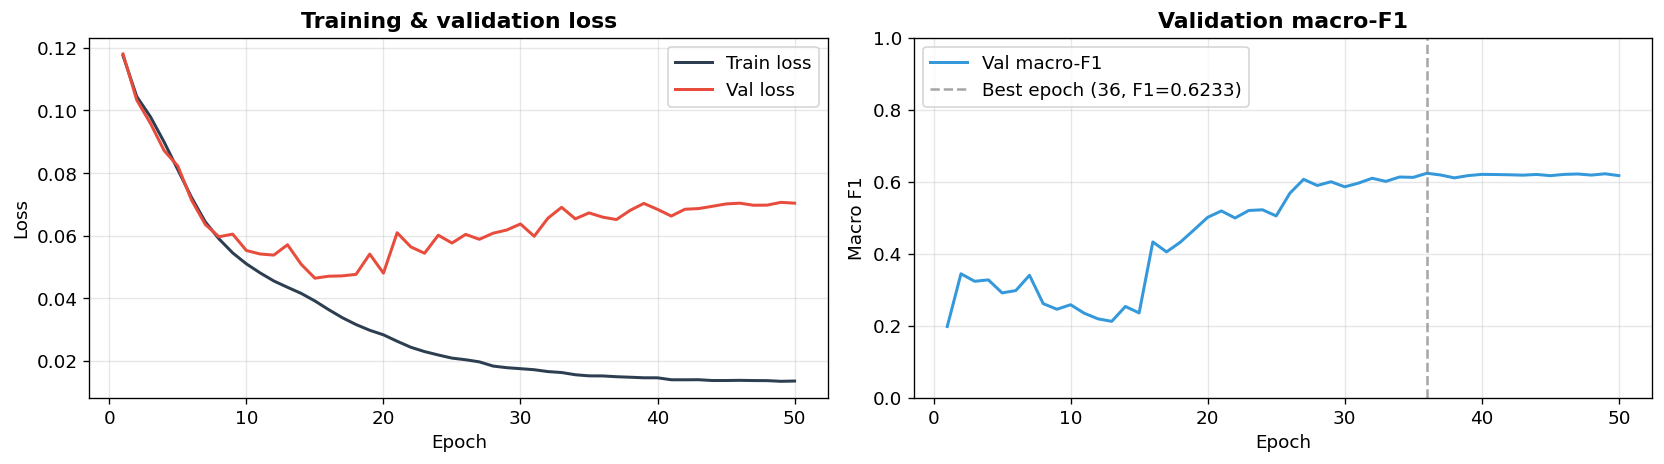

In [10]:
# ── Epoch training curves ──────────────────────────────────────────────────────
colors_cls = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
epochs_ran = list(range(1, len(history['train_loss']) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: train vs val loss
ax = axes[0]
ax.plot(epochs_ran, history['train_loss'], label='Train loss', color='#2c3e50', linewidth=1.8)
ax.plot(epochs_ran, history['val_loss'],   label='Val loss',   color='#e74c3c', linewidth=1.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & validation loss', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: val macro-F1
ax = axes[1]
ax.plot(epochs_ran, history['val_f1'], label='Val macro-F1', color='#3498db', linewidth=1.8)
best_epoch = int(np.argmax(history['val_f1']))
ax.axvline(best_epoch + 1, color='grey', linestyle='--', alpha=0.7,
           label=f'Best epoch ({best_epoch + 1}, F1={max(history["val_f1"]):.4f})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Macro F1')
ax.set_title('Validation macro-F1', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(CKPT_DIR / 'training_curves.png', bbox_inches='tight')
plt.show()

## 8 · Evaluation on test set (best checkpoint)

Load the checkpoint with the best validation loss and run inference on the held-out test set.

In [11]:
# Test-set metrics were computed at the end of the training cell.
# cv_test_probs / cv_test_targets are aliases for test_probs / test_targets,
# consumed by the threshold-tuning cell below.

print(f'Test set: {len(test_probs)} samples  '
      f'(NORM={int((test_targets.sum(axis=1)==0).sum())}, '
      f'multi-label={int((test_targets.sum(axis=1)>1).sum())})')
print()
print(f'{"Class":<6} {"Sensitivity":>12} {"Specificity":>12} {"Accuracy":>10} {"F1":>8}')
print('─' * 52)
for cls in CLASS_NAMES:
    m = test_metrics[cls]
    print(f'{cls:<6} {m["sensitivity"]:>12.4f} {m["specificity"]:>12.4f} '
          f'{m["accuracy"]:>10.4f} {m["f1"]:>8.4f}')
print('─' * 52)
print(f'{"Macro":<6} '
      f'{test_metrics["macro_sensitivity"]:>12.4f} '
      f'{test_metrics["macro_specificity"]:>12.4f} '
      f'{test_metrics["macro_accuracy"]:>10.4f} '
      f'{test_metrics["macro_f1"]:>8.4f}')

Test set: 2449 samples  (NORM=600, multi-label=717)

Class   Sensitivity  Specificity   Accuracy       F1
────────────────────────────────────────────────────
MI           0.5383       0.9336     0.8007   0.6448
STTC         0.6523       0.9061     0.8244   0.7051
CD           0.5245       0.9615     0.8301   0.6498
HYP          0.3719       0.9751     0.8771   0.4958
────────────────────────────────────────────────────
Macro        0.5217       0.9441     0.8331   0.6239


## 8b · Per-class threshold tuning

The default sigmoid threshold of **0.5** is rarely optimal for imbalanced multi-label classification. We grid-search the threshold on the **val set** per class to maximise F1, then apply those thresholds to the test set.


Per-class threshold tuning (val set — no test leakage):
Class   Best thresh    F1 @ 0.50    F1 @ best
----------------------------------------------
MI             0.21       0.6489       0.7236
STTC           0.25       0.7039       0.7448
CD             0.33       0.6525       0.7173
HYP            0.38       0.4879       0.5690

Tuned thresholds: {'MI': np.float64(0.21), 'STTC': np.float64(0.25), 'CD': np.float64(0.33), 'HYP': np.float64(0.38)}


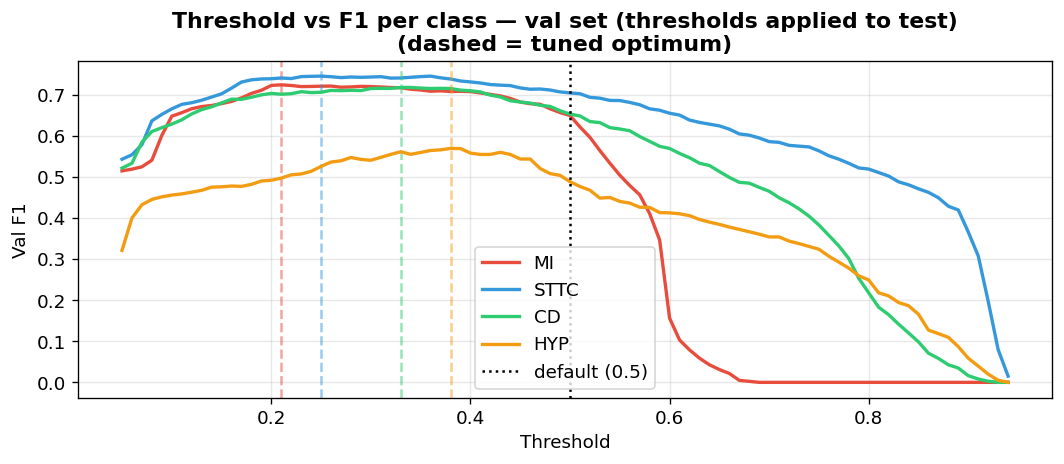


Test set — tuned thresholds (val-tuned) vs default (0.5):
Class    F1@0.50   F1@tuned     Δ F1
-------------------------------------
MI        0.6448     0.7125 +0.0676 ↑
STTC      0.7051     0.7371 +0.0320 ↑
CD        0.6498     0.7011 +0.0512 ↑
HYP       0.4958     0.5361 +0.0403 ↑
-------------------------------------
Macro     0.6239     0.6717 +0.0478


In [12]:
# ── Per-class threshold tuning on validation-set predictions ────────────────────
# Thresholds are tuned on the val set, then applied to the held-out test set.
# This avoids leaking test-set information into the threshold selection.

thresholds_grid   = np.arange(0.05, 0.95, 0.01)
best_thresholds   = {}
thresh_f1_curves  = {}

print('Per-class threshold tuning (val set — no test leakage):')
print(f'{"Class":<6} {"Best thresh":>12} {"F1 @ 0.50":>12} {"F1 @ best":>12}')
print('-' * 46)
for i, cls in enumerate(CLASS_NAMES):
    f1s = [
        f1_score(cv_test_targets[:, i],
                 (cv_test_probs[:, i] >= t).astype(int),
                 zero_division=0)
        for t in thresholds_grid
    ]
    best_t   = thresholds_grid[np.argmax(f1s)]
    f1_at_50 = f1_score(cv_test_targets[:, i],
                        (cv_test_probs[:, i] >= 0.5).astype(int), zero_division=0)
    best_thresholds[cls]   = best_t
    thresh_f1_curves[cls]  = f1s
    print(f'{cls:<6} {best_t:>12.2f} {f1_at_50:>12.4f} {max(f1s):>12.4f}')

print()
print('Tuned thresholds:', {c: round(v, 2) for c, v in best_thresholds.items()})

# ── Plot threshold vs F1 curves ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for cls, col in zip(CLASS_NAMES, colors):
    ax.plot(thresholds_grid, thresh_f1_curves[cls], label=cls, color=col, linewidth=2)
    ax.axvline(best_thresholds[cls], color=col, linestyle='--', alpha=0.5)
ax.axvline(0.5, color='black', linestyle=':', linewidth=1.5, label='default (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Val F1')                                                                                                                                                                           
ax.set_title('Threshold vs F1 per class — val set (thresholds applied to test)\n(dashed = tuned optimum)', fontweight='bold')                                                                                                                                                                   
                                       
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CKPT_DIR / 'threshold_tuning.png', bbox_inches='tight')
plt.show()

# ── Re-evaluate with tuned thresholds ─────────────────────────────────────────
tuned_thresh_arr = np.array([best_thresholds[c] for c in CLASS_NAMES])
preds_tuned      = (test_probs >= tuned_thresh_arr).astype(int)
mcm_tuned        = multilabel_confusion_matrix(test_targets.astype(int), preds_tuned)
test_metrics_tuned = {}
for i, cls in enumerate(CLASS_NAMES):
    tn, fp, fn, tp = mcm_tuned[i].ravel()
    test_metrics_tuned[cls] = dict(
        sensitivity = tp / (tp + fn + 1e-8),
        specificity = tn / (tn + fp + 1e-8),
        accuracy    = (tp + tn) / (tp + tn + fp + fn + 1e-8),
        f1          = 2 * tp / (2 * tp + fp + fn + 1e-8),
    )
for metric in ('sensitivity', 'specificity', 'accuracy', 'f1'):
    test_metrics_tuned[f'macro_{metric}'] = np.mean(
        [test_metrics_tuned[c][metric] for c in CLASS_NAMES]
    )

# test_metrics (default threshold on test set) already set in training cell

print('\nTest set — tuned thresholds (val-tuned) vs default (0.5):')
print(f'{"Class":<6} {"F1@0.50":>9} {"F1@tuned":>10} {"Δ F1":>8}')
print('-' * 37)
for cls in CLASS_NAMES:
    f1_def   = test_metrics[cls]['f1']
    f1_tuned = test_metrics_tuned[cls]['f1']
    delta    = f1_tuned - f1_def
    arrow    = '↑' if delta > 0.001 else ('↓' if delta < -0.001 else '→')
    print(f'{cls:<6} {f1_def:>9.4f} {f1_tuned:>10.4f} {delta:>+7.4f} {arrow}')
print('-' * 37)
print(f'{"Macro":<6} '
      f'{test_metrics["macro_f1"]:>9.4f} '
      f'{test_metrics_tuned["macro_f1"]:>10.4f} '
      f'{test_metrics_tuned["macro_f1"] - test_metrics["macro_f1"]:>+7.4f}')

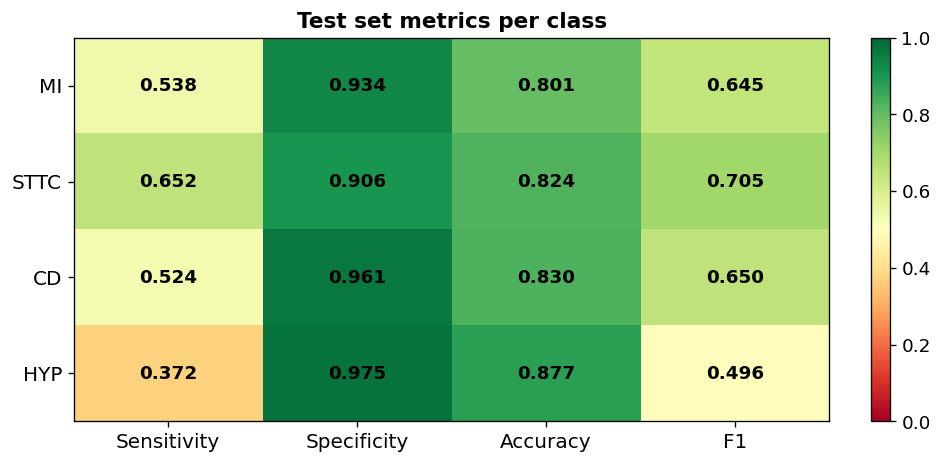

In [13]:
# Metrics heatmap — per class
metric_names = ['Sensitivity', 'Specificity', 'Accuracy', 'F1']
metric_keys  = ['sensitivity', 'specificity', 'accuracy', 'f1']

data = np.array([[test_metrics[cls][k] for k in metric_keys] for cls in CLASS_NAMES])

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(data, vmin=0, vmax=1, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(metric_names))); ax.set_xticklabels(metric_names, fontsize=12)
ax.set_yticks(range(len(CLASS_NAMES)));  ax.set_yticklabels(CLASS_NAMES, fontsize=12)
for i in range(len(CLASS_NAMES)):
    for j in range(len(metric_names)):
        ax.text(j, i, f'{data[i,j]:.3f}', ha='center', va='center',
                fontsize=11, color='black', fontweight='bold')
ax.set_title('Test set metrics per class', fontweight='bold', fontsize=13)
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.savefig(CKPT_DIR / 'metrics_heatmap.png', bbox_inches='tight')
plt.show()

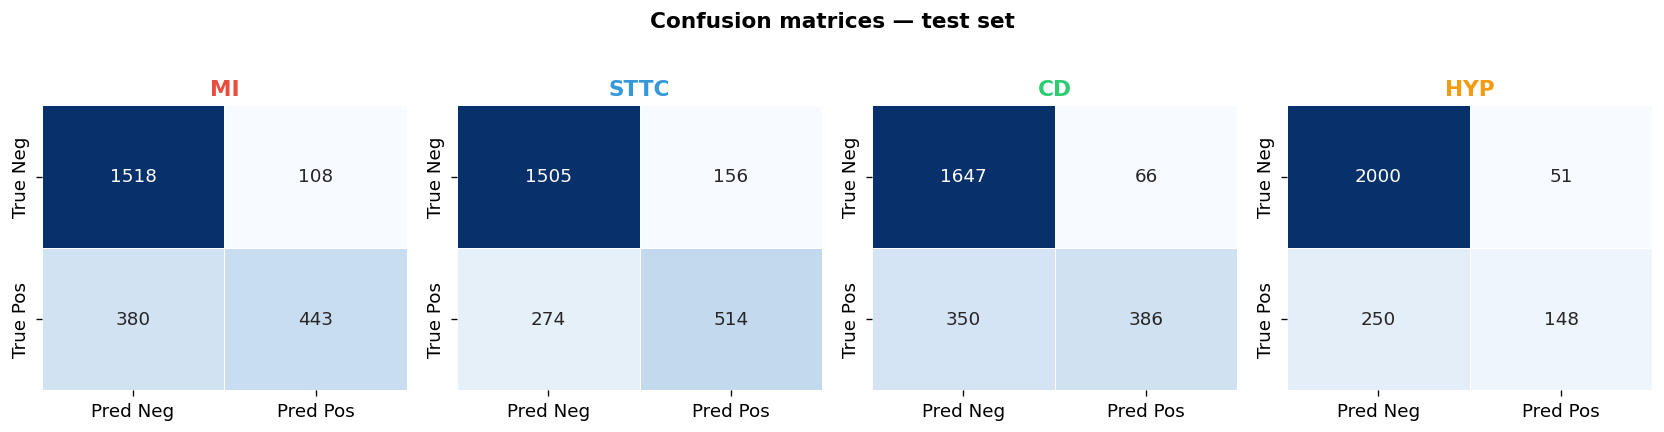

In [14]:
# Confusion matrices (one per class)
preds_bin   = (test_probs >= THRESHOLD).astype(int)
mcm         = multilabel_confusion_matrix(test_targets.astype(int), preds_bin)
COLORS      = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(14, 3.5))
for i, (cls, ax) in enumerate(zip(CLASS_NAMES, axes)):
    cm = mcm[i]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Neg', 'Pred Pos'],
                yticklabels=['True Neg', 'True Pos'],
                cbar=False, linewidths=0.5)
    ax.set_title(cls, fontweight='bold', color=COLORS[i], fontsize=13)

plt.suptitle('Confusion matrices — test set', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(CKPT_DIR / 'confusion_matrices.png', bbox_inches='tight')
plt.show()

## 9 · XAI — Explainability in the medical domain

We use three complementary XAI techniques to make the model interpretable for cardiologists:

| Technique | What it reveals |
|-----------|----------------|
| **GradCAM on CNN** | Which *time windows* in the ECG activated each feature map (temporal saliency) |
| **Integrated Gradients** | Attribution of each individual sample point per lead (fine-grained) |
| **Class activation profiles** | Average activation profile per predicted class (population view) |

In [15]:
# ── Shared XAI constants ──────────────────────────────────────────────────────
LEAD_NAMES = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
TIME_MS    = np.linspace(0, 10_000, 1000)   # 1000 samples at 100 Hz → 10 s

# ── Helper: pick one sample per class from the test set ───────────────────────
def get_class_sample(cls_idx, targets, signals, probs, threshold=THRESHOLD):
    """Return the test sample most confidently predicted positive for a class."""
    mask        = targets[:, cls_idx] == 1
    if mask.sum() == 0:
        mask    = np.ones(len(targets), bool)
    conf_scores = probs[:, cls_idx] * mask
    idx         = np.argmax(conf_scores)
    return idx, signals[idx], targets[idx], probs[idx]


# ── Integrated Gradients ──────────────────────────────────────────────────────
def integrated_gradients(model, x, class_idx, n_steps=50, device=DEVICE):
    """Compute IG attributions. x: (1, 12, 1000). Returns attr: (12, 1000)."""
    baseline = torch.zeros_like(x).to(device)
    x        = x.to(device)
    alphas   = torch.linspace(0, 1, n_steps).to(device)
    grads    = []
    # CuDNN LSTM backward requires training mode
    model.train()
    for alpha in alphas:
        interp = (baseline + alpha * (x - baseline)).requires_grad_(True)
        logit  = model(interp)[0, class_idx]
        model.zero_grad()
        logit.backward()
        grads.append(interp.grad.squeeze(0).cpu())
    model.eval()
    avg_grad = torch.stack(grads).mean(dim=0)           # (12, 1000)
    attr     = ((x.squeeze(0).cpu() - baseline.squeeze(0).cpu()) * avg_grad).numpy()
    return attr


# ── GradCAM for 1-D temporal CNN ─────────────────────────────────────────────
class GradCAM1D:
    """Hooks into a Conv1d layer and computes per-class temporal saliency maps."""

    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        self._fwd_hook   = target_layer.register_forward_hook(self._save_activation)
        self._bwd_hook   = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, x, class_idx):
        """x: (1, 12, 1000) tensor on DEVICE. Returns cam: (T,) numpy array."""
        # CuDNN LSTM backward requires training mode; save and restore afterward.
        was_training = self.model.training
        self.model.train()
        x      = x.requires_grad_(True)
        logits = self.model(x)
        self.model.zero_grad()
        logits[0, class_idx].backward()
        if not was_training:
            self.model.eval()
        weights = self.gradients.mean(dim=-1, keepdim=True)   # (1, C, 1)
        cam     = (weights * self.activations).sum(dim=1)      # (1, T)
        cam     = torch.relu(cam).squeeze().cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

    def remove_hooks(self):
        self._fwd_hook.remove()
        self._bwd_hook.remove()


def find_last_conv(model):
    last_conv = None
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv1d):
            last_conv = module
    return last_conv

target_layer = find_last_conv(model)
print(f'GradCAM target layer: {target_layer}')
print('XAI helpers ready.')


GradCAM target layer: Conv1d(320, 320, kernel_size=(17,), stride=(1,), padding=(8,), bias=False)
XAI helpers ready.


/home/dulat-rakhymkul/Documents/Temp/DataMining/myenv/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: grad and param do not obey the gradient layout contract. This is not an error, but may impair performance.
grad.sizes() = [1, 12, 1000], strides() = [0, 1, 12]
param.sizes() = [1, 12, 1000], strides() = [0, 1, 12] (Triggered internally at /pytorch/torch/csrc/autograd/functions/accumulate_grad.h:242.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


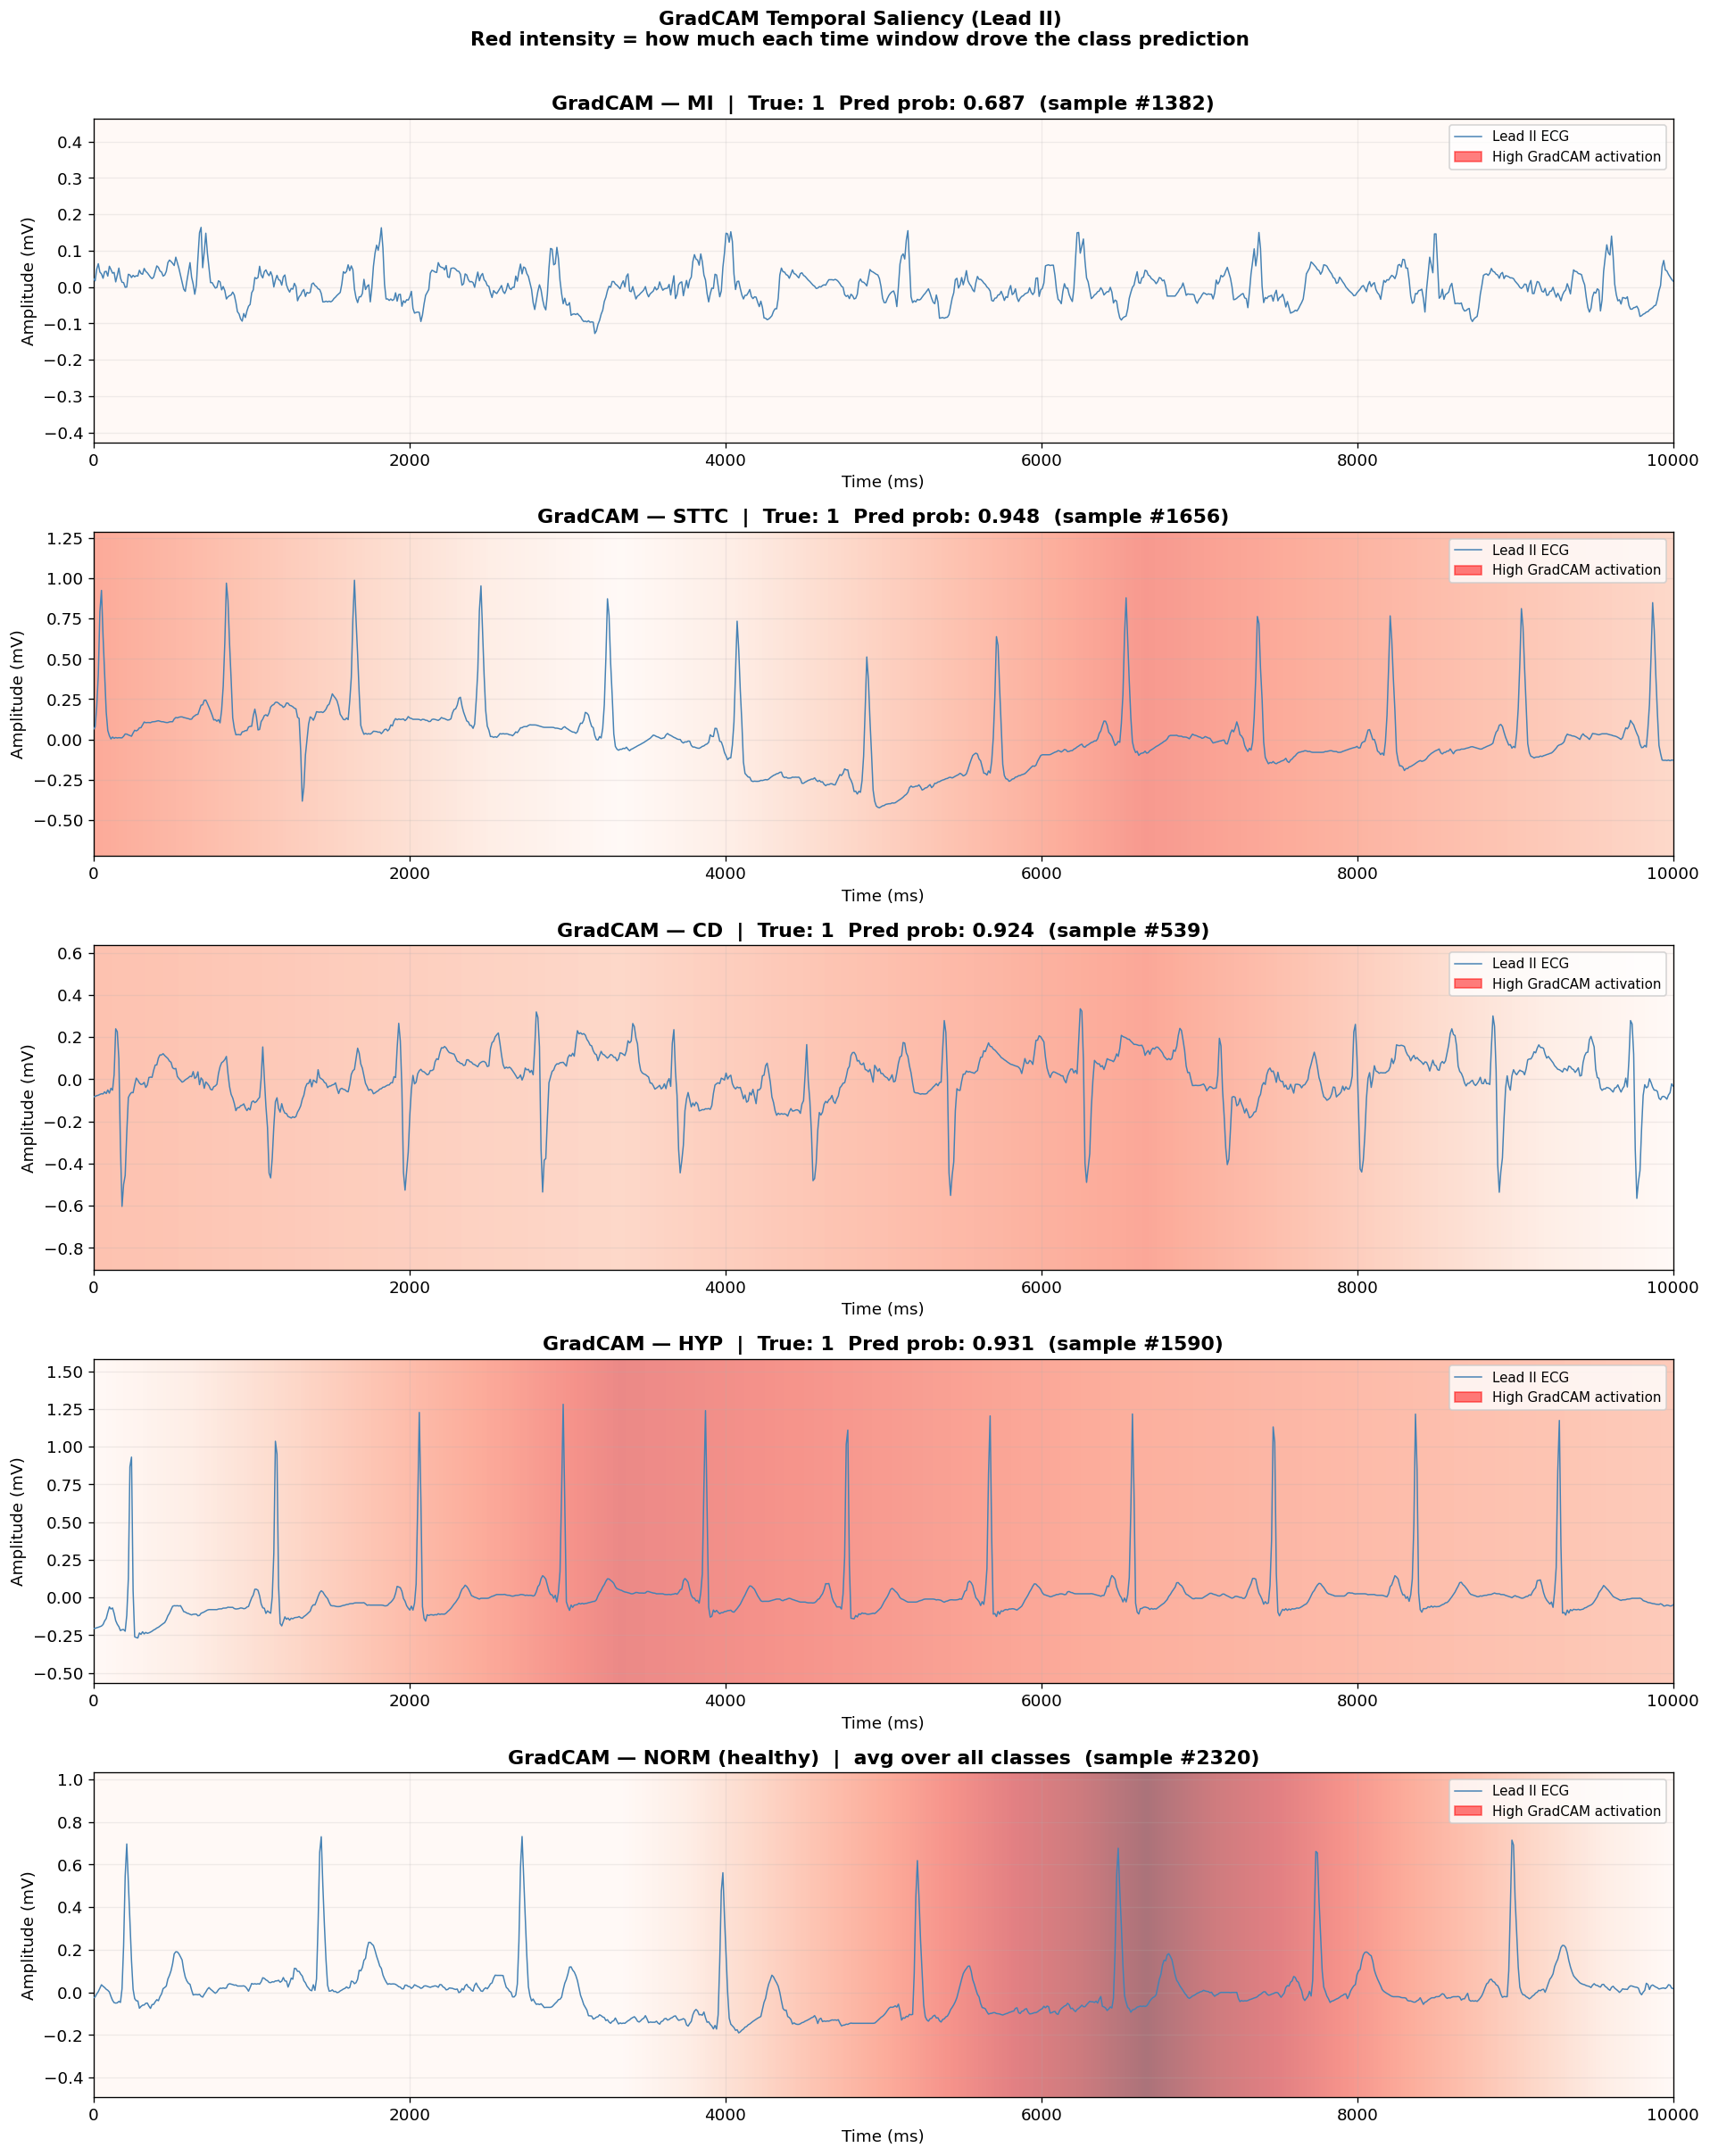

In [16]:
# ── XAI CELL 1: GradCAM temporal saliency (one sample per class + NORM) ────
grad_cam = GradCAM1D(model, target_layer)

norm_mask_test = (test_targets.sum(axis=1) == 0)
preds_bin_test_cam = (test_probs >= THRESHOLD).astype(int)
norm_correct   = norm_mask_test & (preds_bin_test_cam.sum(axis=1) == 0)

cam_groups = []
for cls_idx, cls in enumerate(CLASS_NAMES):
    idx, sig, tgt, prob = get_class_sample(cls_idx, test_targets, X_test, test_probs)
    cam_groups.append((cls, cls_idx, idx, sig, tgt, prob))

if norm_correct.sum() > 0:
    norm_conf = 1 - test_probs[norm_correct].max(axis=1)
    norm_idx  = np.where(norm_correct)[0][np.argmax(norm_conf)]
    cam_groups.append((
        "NORM (healthy)", -1, norm_idx,
        X_test[norm_idx], test_targets[norm_idx], test_probs[norm_idx]
    ))

n_panels = len(cam_groups)
fig, axes = plt.subplots(n_panels, 1, figsize=(16, 4 * n_panels))
if n_panels == 1:
    axes = [axes]

panel_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for (cls, cls_idx, sample_idx, sig, tgt, prob), ax in zip(cam_groups, axes):
    x_tensor = torch.tensor(sig[np.newaxis], dtype=torch.float32).to(DEVICE)

    if cls_idx >= 0:
        cam = grad_cam.generate(x_tensor, cls_idx)
    else:
        cams = [grad_cam.generate(x_tensor, ci) for ci in range(NUM_CLASSES)]
        cam  = np.mean(cams, axis=0)
        cam  = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    cam_up = np.interp(np.linspace(0, 1, 1000), np.linspace(0, 1, len(cam)), cam)

    lead_signal = sig[1]   # lead II
    ymin, ymax  = lead_signal.min() - 0.3, lead_signal.max() + 0.3

    # pcolormesh with shading='flat': C must be (nrows-1, ncols-1)
    # X has 1001 edges, Y has 2 edges → C must be (1, 1000)
    cam_2d  = cam_up[np.newaxis, :]                        # (1, 1000)
    t_edges = np.linspace(TIME_MS[0], TIME_MS[-1], 1001)  # 1001 bin edges
    y_edges = [ymin, ymax]                                 # 2 bin edges
    ax.pcolormesh(t_edges, y_edges, cam_2d,
                  cmap='Reds', alpha=0.55, vmin=0, vmax=1, shading='flat')

    ax.plot(TIME_MS, lead_signal, color='steelblue', linewidth=0.9,
            label='Lead II ECG', zorder=3)

    red_patch = mpatches.Patch(color='red', alpha=0.5, label='High GradCAM activation')

    is_norm = cls_idx < 0
    title_suffix = 'avg over all classes' if is_norm else \
        f'True: {int(tgt[cls_idx])}  Pred prob: {prob[cls_idx]:.3f}'
    ax.set_title(
        f'GradCAM — {cls}  |  {title_suffix}  (sample #{sample_idx})',
        fontweight='bold'
    )
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Amplitude (mV)')
    ax.set_ylim(ymin, ymax)
    ax.legend(handles=[ax.lines[0], red_patch], loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.2)

grad_cam.remove_hooks()
plt.suptitle(
    'GradCAM Temporal Saliency (Lead II)\n'
    'Red intensity = how much each time window drove the class prediction',
    fontweight='bold', fontsize=13, y=1.005
)
plt.tight_layout()
plt.savefig(CKPT_DIR / 'xai_gradcam.png', bbox_inches='tight')
plt.show()


Computing Integrated Gradients for class MI (sample #1382) …


Attribution shape: (12, 1000)  (leads x time)


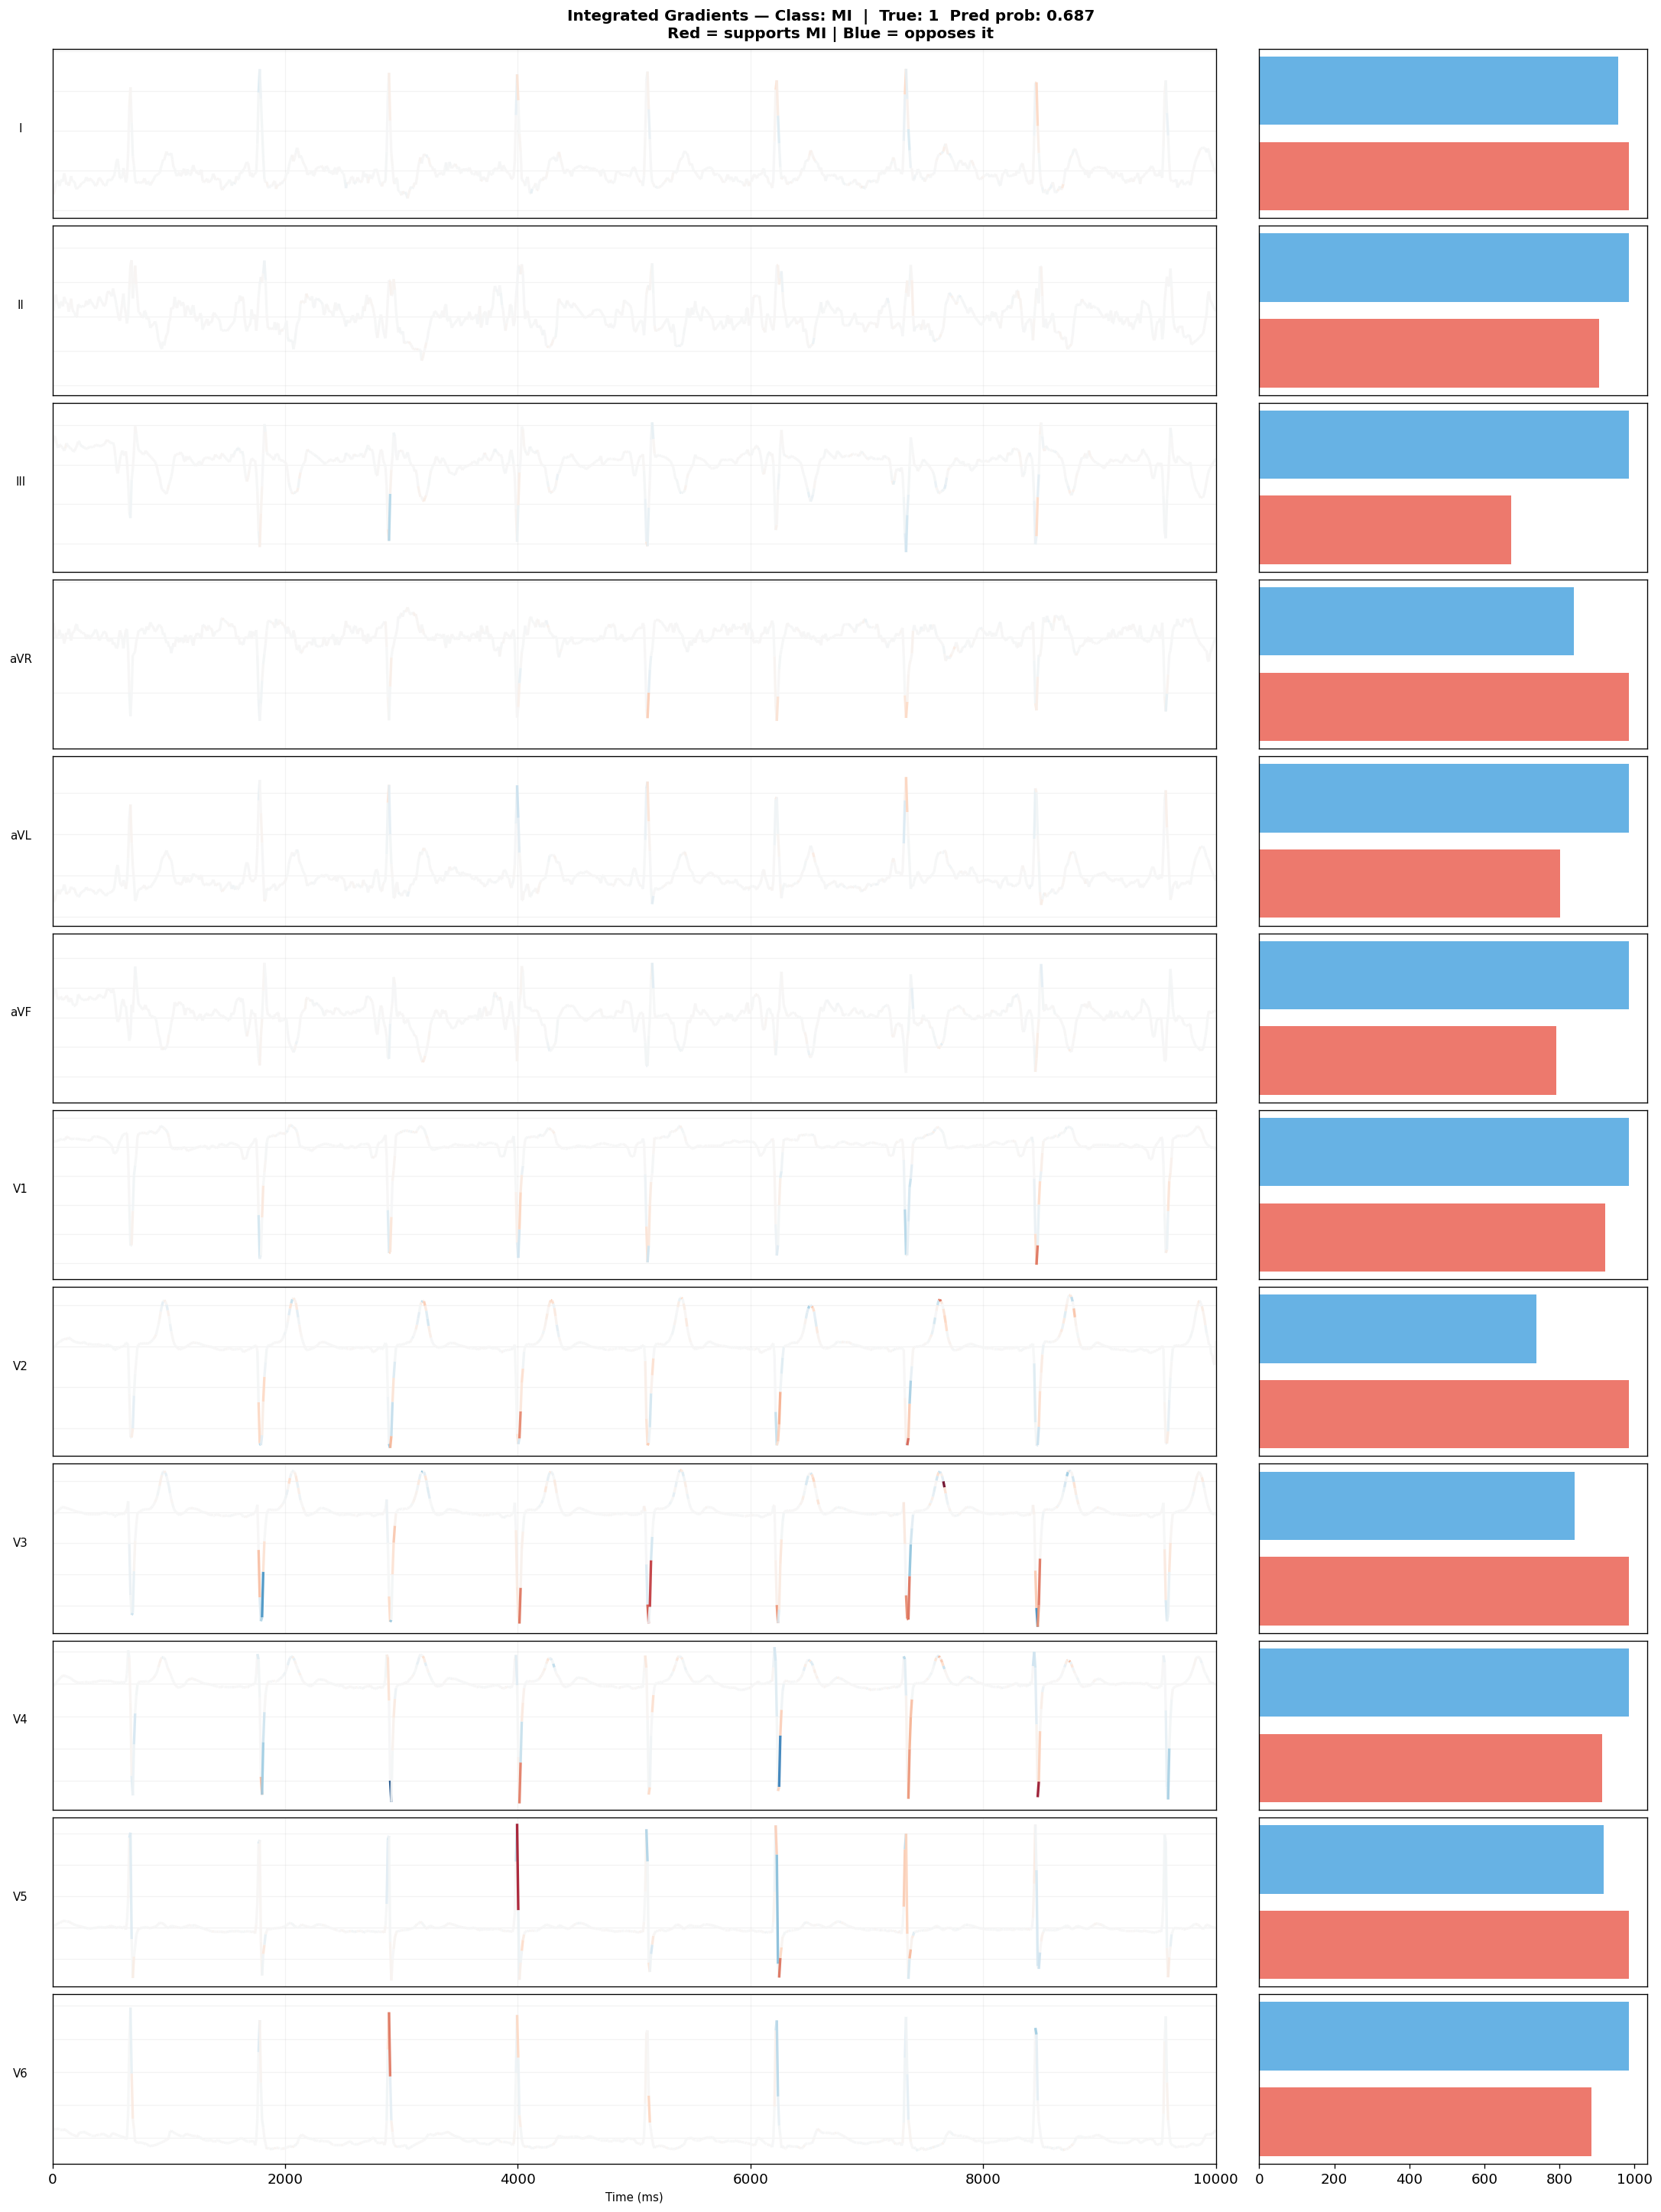

In [17]:
# ── XAI CELL 2: Integrated Gradients (all 12 leads, one sample) ───────────────
#
# Each amplitude point is attributed a signed score:
#   Red  → pushes the prediction TOWARD the positive class
#   Blue → pushes the prediction AWAY from the positive class
#
# Medical interpretation:
#   A cardiologist can see exactly which deflections (P, QRS, T waves)
#   drive the classification on each of the 12 leads.
#   Strong red clusters on V1-V4 in an MI sample = ST-elevation territory.

from matplotlib.collections import LineCollection
import matplotlib.cm as cm

# Pick a MI sample for demo (most clinically compelling)
demo_cls_idx = 0   # MI
demo_cls     = CLASS_NAMES[demo_cls_idx]
sample_idx, sig, tgt, prob = get_class_sample(demo_cls_idx, test_targets, X_test, test_probs)
x_tensor = torch.tensor(sig[np.newaxis], dtype=torch.float32)

print(f'Computing Integrated Gradients for class {demo_cls} (sample #{sample_idx}) …')
attr = integrated_gradients(model, x_tensor, demo_cls_idx, n_steps=50)
print(f'Attribution shape: {attr.shape}  (leads x time)')

fig, axes = plt.subplots(12, 2, figsize=(18, 24),
                         gridspec_kw={'width_ratios': [3, 1]},
                         constrained_layout=True)

abs_max_attr = np.abs(attr).max()
cmap_rg      = plt.get_cmap('RdBu_r')   # red=positive, blue=negative

for lead_i, lead_name in enumerate(LEAD_NAMES):
    ax_sig, ax_bar = axes[lead_i]

    signal  = sig[lead_i]         # (1000,)
    attribs = attr[lead_i]        # (1000,)
    norm_a  = attribs / (abs_max_attr + 1e-8)   # −1 … +1

    # ── LineCollection: colour each segment by attribution (vectorised) ──
    points  = np.array([TIME_MS, signal]).T.reshape(-1, 1, 2)   # (T,1,2)
    segs    = np.concatenate([points[:-1], points[1:]], axis=1)  # (T-1,2,2)
    lc      = LineCollection(segs, cmap=cmap_rg, norm=plt.Normalize(-1, 1),
                             linewidth=2.0, alpha=0.9)
    lc.set_array(norm_a[:-1])
    ax_sig.add_collection(lc)
    ax_sig.set_xlim(TIME_MS[0], TIME_MS[-1])
    ax_sig.set_ylim(signal.min() - 0.1, signal.max() + 0.1)

    ax_sig.set_ylabel(lead_name, fontsize=9, rotation=0, labelpad=25)
    ax_sig.tick_params(left=False, labelleft=False)
    ax_sig.grid(True, alpha=0.15)
    if lead_i < 11:
        ax_sig.tick_params(bottom=False, labelbottom=False)
    else:
        ax_sig.set_xlabel('Time (ms)', fontsize=9)

    # Bar: total positive vs. absolute negative attribution
    pos_sum = attribs[attribs > 0].sum() if (attribs > 0).any() else 0
    neg_sum = -attribs[attribs < 0].sum() if (attribs < 0).any() else 0
    ax_bar.barh(['Supports', 'Opposes'], [pos_sum, neg_sum],
               color=['#e74c3c', '#3498db'], alpha=0.75)
    ax_bar.set_xlim(0, None)
    ax_bar.tick_params(left=False, labelleft=False)
    if lead_i < 11:
        ax_bar.tick_params(bottom=False, labelbottom=False)

fig.suptitle(
    f'Integrated Gradients — Class: {demo_cls}  |  '
    f'True: {int(tgt[demo_cls_idx])}  Pred prob: {prob[demo_cls_idx]:.3f}\n'
    f'Red = supports {demo_cls} | Blue = opposes it',
    fontweight='bold', fontsize=12
)
plt.savefig(CKPT_DIR / f'xai_integrated_gradients_{demo_cls}.png', bbox_inches='tight')
plt.show()


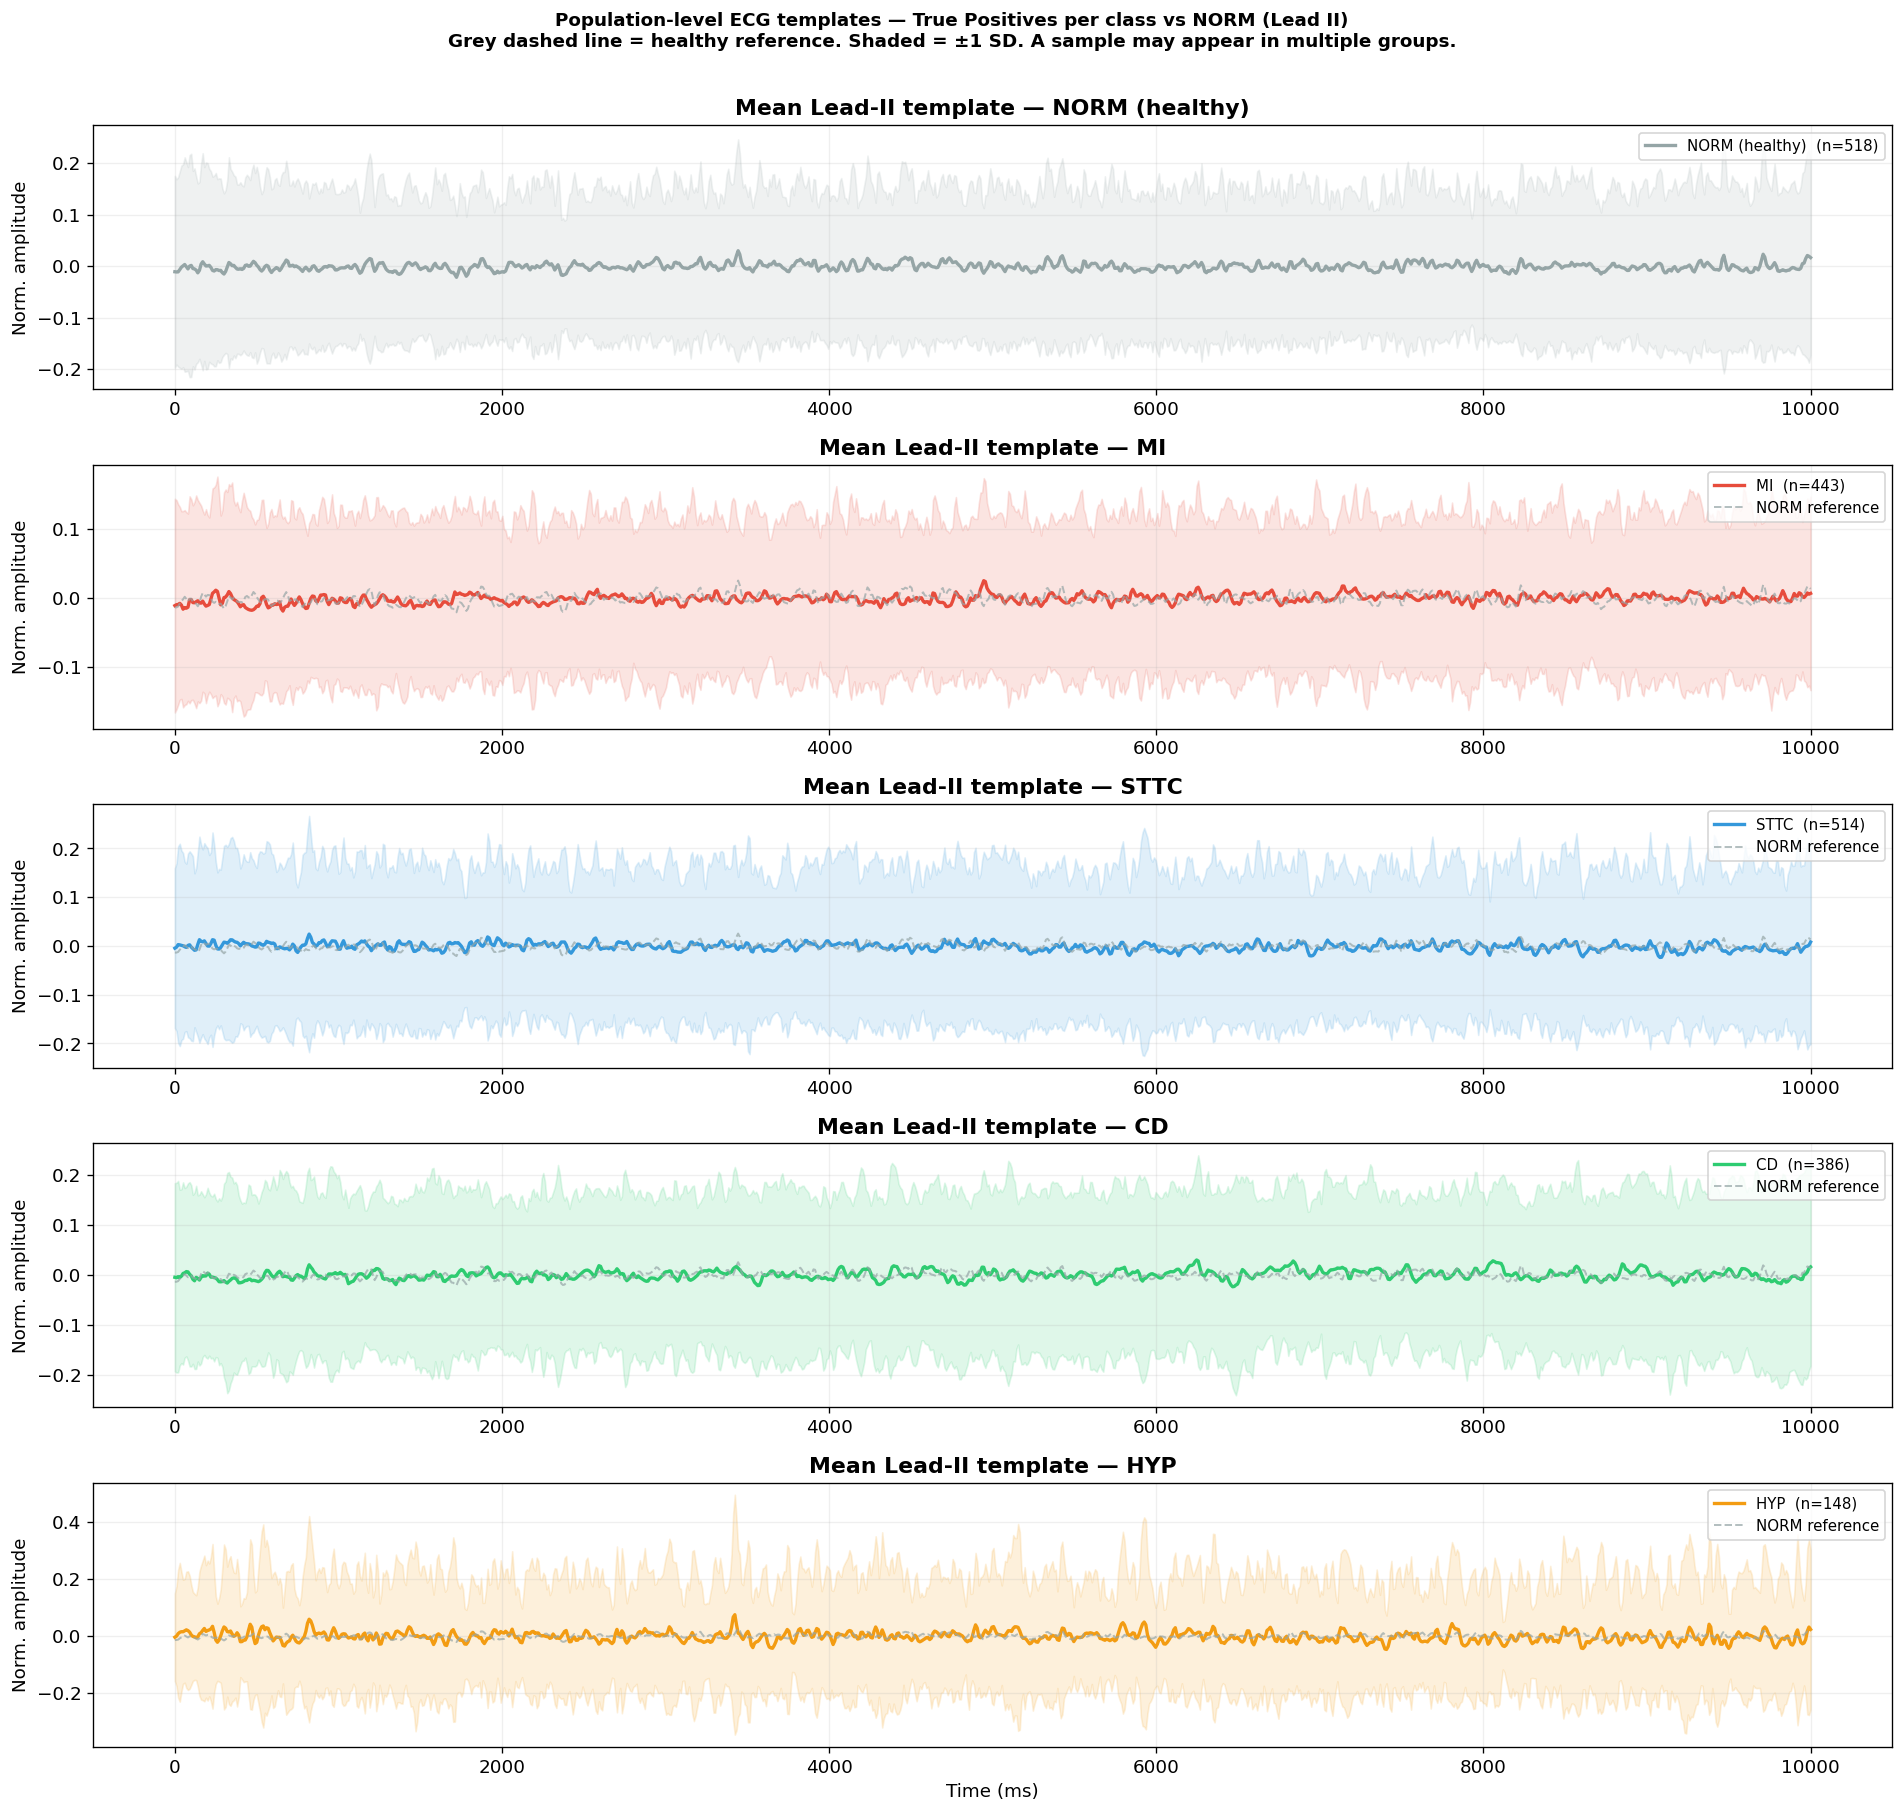

In [18]:
# ── XAI CELL 3: Population-level mean activation per predicted class ──────────
#
# Average the ECG signal over all correctly predicted positives for each class,
# plus a NORM (healthy, all-label-zero) group for reference.
# Samples can be positive for multiple classes simultaneously — the template
# represents the average morphology for that label, not an exclusive subgroup.
#
# Medical interpretation:
#   Compare each class template against the NORM template to visually verify
#   that the model has learned clinically meaningful waveform differences:
#   MI → ST elevation / Q waves; CD → wide QRS; HYP → high voltage; STTC → T-wave changes.

preds_bin_test = (test_probs >= THRESHOLD).astype(int)

# Include NORM (healthy) as an extra group
norm_mask_test  = (test_targets.sum(axis=1) == 0)
groups          = [('NORM (healthy)', norm_mask_test & (preds_bin_test.sum(axis=1) == 0), '#95a5a6')]
for cls_idx, cls in enumerate(CLASS_NAMES):
    tp_mask = (test_targets[:, cls_idx] == 1) & (preds_bin_test[:, cls_idx] == 1)
    groups.append((cls, tp_mask, ['#e74c3c','#3498db','#2ecc71','#f39c12'][cls_idx]))

fig, axes = plt.subplots(len(groups), 1, figsize=(16, 3 * len(groups)))

for (label, mask, color), ax in zip(groups, axes):
    if mask.sum() == 0:
        ax.set_title(f'{label}: no samples found')
        continue

    mean_sig = X_test[mask][:, 1, :].mean(axis=0)   # lead II
    std_sig  = X_test[mask][:, 1, :].std(axis=0)
    ax.plot(TIME_MS, mean_sig, color=color, linewidth=2,
            label=f'{label}  (n={mask.sum()})')
    ax.fill_between(TIME_MS, mean_sig - std_sig, mean_sig + std_sig,
                    color=color, alpha=0.15)

    # Overlay the NORM mean as a grey reference on disease panels
    if label != 'NORM (healthy)' and norm_mask_test.sum() > 0:
        norm_mean = X_test[norm_mask_test][:, 1, :].mean(axis=0)
        ax.plot(TIME_MS, norm_mean, color='#95a5a6', linewidth=1.2,
                linestyle='--', alpha=0.7, label='NORM reference')

    ax.set_title(f'Mean Lead-II template — {label}', fontweight='bold')
    ax.set_ylabel('Norm. amplitude')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Time (ms)')
plt.suptitle(
    'Population-level ECG templates — True Positives per class vs NORM (Lead II)\n'
    'Grey dashed line = healthy reference. Shaded = ±1 SD. A sample may appear in multiple groups.',
    fontweight='bold', fontsize=11, y=1.005
)
plt.tight_layout()
plt.savefig(CKPT_DIR / 'xai_mean_activation_profiles.png', bbox_inches='tight')
plt.show()


Computing lead importance for MI over 20 samples …


Computing lead importance for STTC over 20 samples …
Computing lead importance for CD over 20 samples …
Computing lead importance for HYP over 20 samples …


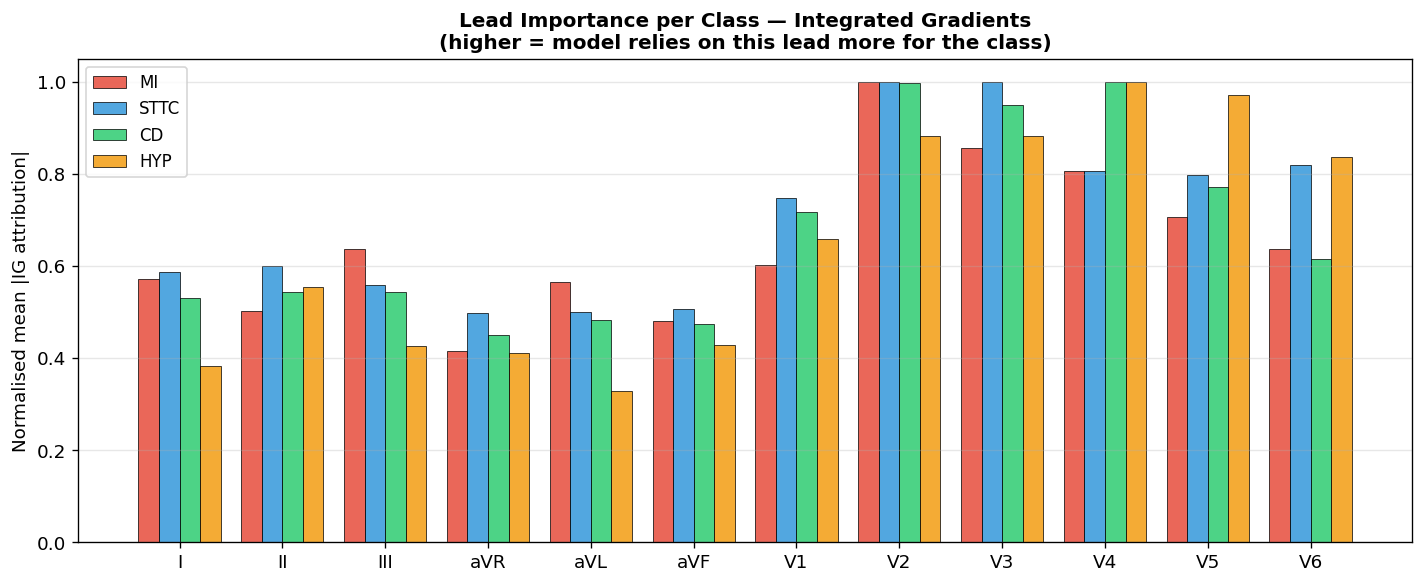


Clinical context:
  MI   → typically manifests in precordial leads (V1-V4) and inferior leads (II, III, aVF)
  CD   → QRS morphology visible in all leads; LBBB patterns prominent in lateral leads
  HYP  → high-voltage QRS in precordial leads; left axis deviation in limb leads
  STTC → ST/T changes across multiple leads depending on territory


In [19]:
# ── XAI CELL 4: Lead importance via attribution aggregation ───────────────────
#
# For each class, compute mean |IG attribution| per lead over all TP samples.
# This shows which leads the model relies on most — clinically, different classes
# should involve specific leads (e.g., MI often manifests in V1-V4 or II/III/aVF).

N_EXPLAIN  = 20   # number of samples per class to explain (expensive)
lead_importance = np.zeros((NUM_CLASSES, 12))

for cls_idx, cls in enumerate(CLASS_NAMES):
    tp_mask = (test_targets[:, cls_idx] == 1) & (preds_bin_test[:, cls_idx] == 1)
    tp_indices = np.where(tp_mask)[0][:N_EXPLAIN]

    if len(tp_indices) == 0:
        continue

    print(f'Computing lead importance for {cls} over {len(tp_indices)} samples …')
    attrs_all = []
    for idx in tp_indices:
        x_t  = torch.tensor(X_test[idx][np.newaxis], dtype=torch.float32)
        attr = integrated_gradients(model, x_t, cls_idx, n_steps=30)
        attrs_all.append(np.abs(attr).mean(axis=1))   # mean |attr| per lead (12,)

    lead_importance[cls_idx] = np.mean(attrs_all, axis=0)   # (12,)

# Normalise per class for comparability
lead_imp_norm = lead_importance / (lead_importance.max(axis=1, keepdims=True) + 1e-8)

fig, ax = plt.subplots(figsize=(12, 5))
x_pos   = np.arange(12)
width   = 0.2
colors  = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors)):
    ax.bar(x_pos + i * width, lead_imp_norm[i], width, label=cls, color=col, alpha=0.85, edgecolor='k', linewidth=0.5)

ax.set_xticks(x_pos + width * 1.5)
ax.set_xticklabels(LEAD_NAMES, fontsize=11)
ax.set_ylabel('Normalised mean |IG attribution|', fontsize=11)
ax.set_title('Lead Importance per Class — Integrated Gradients\n'
             '(higher = model relies on this lead more for the class)',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(CKPT_DIR / 'xai_lead_importance.png', bbox_inches='tight')
plt.show()

print()
print('Clinical context:')
print('  MI   → typically manifests in precordial leads (V1-V4) and inferior leads (II, III, aVF)')
print('  CD   → QRS morphology visible in all leads; LBBB patterns prominent in lateral leads')
print('  HYP  → high-voltage QRS in precordial leads; left axis deviation in limb leads')
print('  STTC → ST/T changes across multiple leads depending on territory')

## 10 · Summary & saved artefacts

In [20]:
print('=' * 60)
print('  FINAL SUMMARY')
print('=' * 60)
print(f'\nDataset: {len(X_bal)} samples  '
      f'(NORM undersampled to {NORM_CAP} from {(y_all.sum(axis=1)==0).sum()})')
print(f'Split:   {len(X_train_split)} train / {len(X_val_split)} val / {len(X_test_split)} test  (70/15/15)')
print()
print('Test set performance:')
print(f'{"Class":<6} {"Sensitivity":>12} {"Specificity":>12} {"Accuracy":>10} {"F1":>8}')
print('-' * 52)
for cls in CLASS_NAMES:
    m = test_metrics[cls]
    print(f'{cls:<6} {m["sensitivity"]:>12.4f} {m["specificity"]:>12.4f} '
          f'{m["accuracy"]:>10.4f} {m["f1"]:>8.4f}')
print('-' * 52)
print(f'{"Macro":<6} '
      f'{test_metrics["macro_sensitivity"]:>12.4f} '
      f'{test_metrics["macro_specificity"]:>12.4f} '
      f'{test_metrics["macro_accuracy"]:>10.4f} '
      f'{test_metrics["macro_f1"]:>8.4f}')

print()
print('Saved artefacts in', CKPT_DIR)
for f in sorted(CKPT_DIR.iterdir()):
    if f.is_file():
        size = f.stat().st_size / 1024
        print(f'  {f.name:<45} {size:7.1f} KB')

  FINAL SUMMARY

Dataset: 16347 samples  (NORM undersampled to 4000 from 9083)
Split:   11474 train / 2424 val / 2449 test  (70/15/15)

Test set performance:
Class   Sensitivity  Specificity   Accuracy       F1
----------------------------------------------------
MI           0.5383       0.9336     0.8007   0.6448
STTC         0.6523       0.9061     0.8244   0.7051
CD           0.5245       0.9615     0.8301   0.6498
HYP          0.3719       0.9751     0.8771   0.4958
----------------------------------------------------
Macro        0.5217       0.9441     0.8331   0.6239

Saved artefacts in checkpoints
  best_model.pt                                 33264.8 KB
  confusion_matrices.png                           35.3 KB
  label_distribution.png                           74.0 KB
  metrics_heatmap.png                              44.8 KB
  threshold_tuning.png                             89.9 KB
  training_curves.png                              74.7 KB
  xai_gradcam.png               